In [1]:
import torch, torchvision
import torch.nn as nn
import torch.backends.cudnn as cudnn

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

import json, os

from shared import load_cifar, create_classification, train_model, free_mem, freeze_model, plot_line, set_neurips_style

set_neurips_style()
cudnn.benchmark = True
plt.ion();

# 4. Transfer Learning and Generalization

In [2]:
BASE = "cifar10-data"
BASE_PLOTS = os.path.join(BASE, "plots")
BASE_MODELS = os.path.join(BASE, "models")

os.makedirs(BASE_PLOTS, exist_ok=True)
os.makedirs(BASE_MODELS, exist_ok=True)

In [3]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
BATCH_SIZE = 64
LR = 0.001
MOMENTUM = 0.9
STEP_SIZE = 7
GAMMA = 0.1
N_EPOCHS = 5

print(f"Using {DEVICE=}")

Using DEVICE='cuda'


In [4]:
dataloaders, dataset_sizes = load_cifar(batch_size=BATCH_SIZE, num_workers=4)

In [5]:
def load_model(pretrained=True):
    weights = torchvision.models.ResNet152_Weights.IMAGENET1K_V1 if pretrained else None
    return torchvision.models.resnet152(weights=weights)

def add_clf_head(resnet):
    n_features = resnet.fc.in_features
    resnet.fc = nn.Linear(n_features, 10, bias=True)
    return resnet

## Random Weights, Full Finetuning

In [6]:
model = add_clf_head(load_model(pretrained=False)).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 58164298


In [7]:
if not os.path.exists(os.path.join(BASE_MODELS, "cnn-task_random-full.json")):
    train_model(os.path.join(BASE_MODELS, "cnn-task_random-full"), model, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Training complete in 34m 42s
Best val Acc: 0.450600


In [8]:
del model
del criterion
del optimizer
del exp_sched

free_mem()

## Pretrained Weights, Full Finetuning

In [7]:
model = add_clf_head(load_model(pretrained=True)).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 58164298


In [10]:
if not os.path.exists(os.path.join(BASE_MODELS, "cnn-task_pretrained-full.json")):
    train_model(os.path.join(BASE_MODELS, "cnn-task_pretrained-full"), model, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Training complete in 34m 34s
Best val Acc: 0.970500


In [11]:
del model
del criterion
del optimizer
del exp_sched

free_mem()

## Random Weights, Final Block Finetuning

In [8]:
model = add_clf_head(freeze_model(load_model(pretrained=False))).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model.fc, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 20490


In [13]:
if not os.path.exists(os.path.join(BASE_MODELS, "cnn-task_random-final-block")):
    train_model(os.path.join(BASE_MODELS, "cnn-task_random-final-block"), model, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Training complete in 13m 24s
Best val Acc: 0.159800


In [14]:
del model
del criterion
del optimizer
del exp_sched

free_mem()

## Pretrained Weights, Final Block Finetuning

In [9]:
model = add_clf_head(freeze_model(load_model(pretrained=True))).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model.fc, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 20490


In [16]:
if not os.path.exists(os.path.join(BASE_MODELS, "cnn-task_pretrained-final-block")):
    train_model(os.path.join(BASE_MODELS, "cnn-task_pretrained-final-block"), model, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Training complete in 13m 25s
Best val Acc: 0.779800


In [17]:
del model
del criterion
del optimizer
del exp_sched

free_mem()

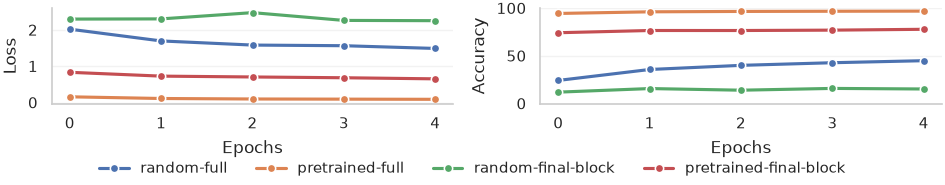

In [3]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(6.5, 1.35))

for fname in ["cnn-task_random-full", "cnn-task_pretrained-full", "cnn-task_random-final-block", "cnn-task_pretrained-final-block"]:
    with open(os.path.join(BASE_MODELS, f"{fname}.json"), "r") as f:
        perf = json.loads(f.read())

    perf_df = pd.DataFrame(perf["val"]).copy()
    perf_df["accuracy"] = perf_df["accuracy"]*100
    label = fname.split("_")[-1]
    lineplot_kwargs = dict(linewidth=1.5, label=label)
    
    configs = [
        {
            "column": "loss",
            "title": "",
            "xlabel": "Epochs",
            "ylabel": "Loss",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax1},
        },
        {
            "column": "accuracy",
            "title": "",
            "xlabel": "Epochs",
            "ylabel": "Accuracy",
            "ylim": (0,100),
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax2},
        },
    ]
    
    plot_line(perf_df, configs)


handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=7,
    bbox_to_anchor=(0.5, -0.01),
)

for ax in [ax1, ax2]:
    ax.grid(axis="y", alpha=0.25, linewidth=0.7)
    ax.grid(axis="x", visible=False)
    ax.legend_.remove()
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))

fig.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(os.path.join(BASE_PLOTS, "random-vs-pretrained.pdf"), bbox_inches="tight", dpi=300)
plt.show()